In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

step 1

In [ ]:
df=pd.read_csv(r'retail_sales_dataset.csv')
print("🔍 First 5 Rows:")
print(df.head())

step 2

In [ ]:


print("✅ Loaded successfully! ")
print(f'the shape : {df.shape}')
print(f'the rows  : {len(df):,}')
print(f'the columns : {df.columns}')
# print(f'the rows  : {df.index}')


In [33]:
print("\n📋 Column Types:")
print(df.info())



📋 Column Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [25]:
print(df.describe())

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


In [26]:
# Overview of each column
col_info=pd.DataFrame({
    'Types': df.dtypes ,
    'Unique': [df[i].nunique() for i in df.columns] ,
    'Sample' : [str(df[i].iloc[0]) for i in df.columns]
})

print(col_info)


                   Types  Unique      Sample
Transaction ID     int64    1000           1
Date              object     345  2023-11-24
Customer ID       object    1000     CUST001
Gender            object       2        Male
Age                int64      47          34
Product Category  object       3      Beauty
Quantity           int64       4           3
Price per Unit     int64       5          50
Total Amount       int64      18         150


step 3

In [37]:
# Data cleaning
print(df.isnull().sum())
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df['Date']=pd.to_datetime(df['Date'])
# print(df.info())
print("Data is clean")

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Data is clean


step 4

In [ ]:
# Best-selling products
top_products=df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print('\nTOP Products ', top_products)

# Highest month in sales
df['Month']=df['Date'].dt.month
month_sales=df.groupby('Month')['Total Amount'].sum().sort_values(ascending=False)
print( f' Monthly Sales {month_sales} ')




TOP Products  Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64
 Monthly Sales Month
5     53150
10    46580
12    44690
2     44060
1     36980
8     36960
6     36715
7     35465
11    34920
4     33870
3     28990
9     23620
Name: Total Amount, dtype: int64 
 The average value of a single order Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64 
The age group that spends the most Age
18    11215
19    14870
20     8645
21    12585
22    13700
23     8220
24     5415
25     9900
26    13980
27     9385
28     8670
29     6570
30     9790
31    10220
32     5550
33     6240
34    16785
35    11290
36     9105
37    11650
38    11100
39     4595
40     9415
41     5650
42     8500
43    17970
44     7560
45     6325
46    13090
47    12505
48     7240
49     5110
50     9845
51    16065
52     7040
53     9510
54    10505
55     9780
56     

In [ ]:
# What is the average value of a single order
average_value_of_single_order=df.groupby('Product Category')['Total Amount'].mean()
print( f' The average value of a single order {average_value_of_single_order} ')

# The age group that spends the most
age_group=df.groupby('Age')['Total Amount'].sum().sort_values(ascending=False)
print('The age group that spends the most',age_group)



 The average value of a single order Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64 
The age group that spends the most Age
43    17970
34    16785
51    16065
19    14870
26    13980
22    13700
46    13090
21    12585
47    12505
37    11650
60    11590
35    11290
18    11215
38    11100
54    10505
31    10220
25     9900
50     9845
30     9790
55     9780
53     9510
59     9470
56     9440
40     9415
27     9385
57     9290
63     9250
64     9125
36     9105
28     8670
20     8645
42     8500
23     8220
62     8120
44     7560
58     7395
48     7240
52     7040
61     6730
29     6570
45     6325
33     6240
41     5650
32     5550
24     5415
49     5110
39     4595
Name: Total Amount, dtype: int64
Gender influences the type of product purchased ? : YES                           Transaction ID  Date  Customer ID  Age  Quantity  \
Gender Product Category                                       

In [84]:
# Gender influences the type of product purchased ?
Gender_influences=df.groupby(['Gender','Product Category'])['Transaction ID'].count()
Gender_influences

Gender  Product Category
Female  Beauty              166
        Clothing            174
        Electronics         170
Male    Beauty              141
        Clothing            177
        Electronics         172
Name: Transaction ID, dtype: int64

step 5

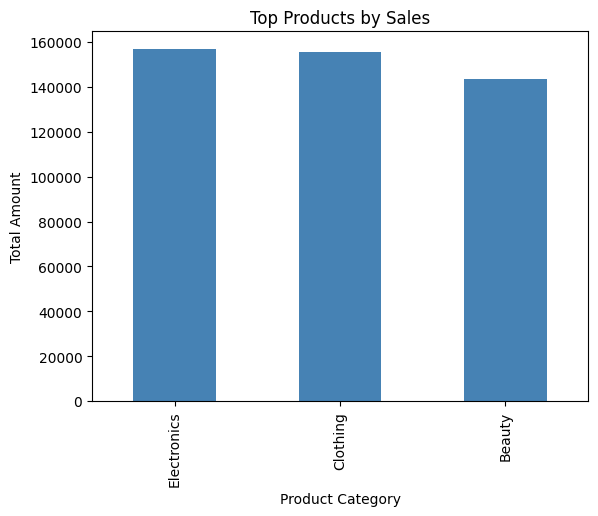

In [134]:
top_products.plot(kind='bar', color='steelblue')
plt.title('Top Products by Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.savefig('top_products.png',dpi=300,bbox_inches='tight')
plt.show()

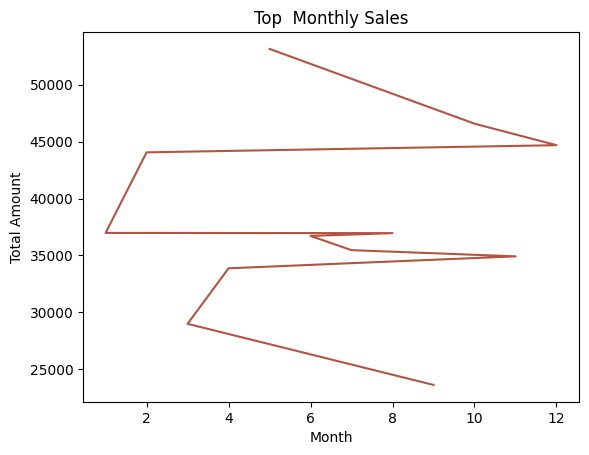

In [135]:
month_sales.plot(kind='line',color='#B35442')
plt.title('Top  Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.savefig('month_sales.png',dpi=300,bbox_inches='tight')
plt.show()

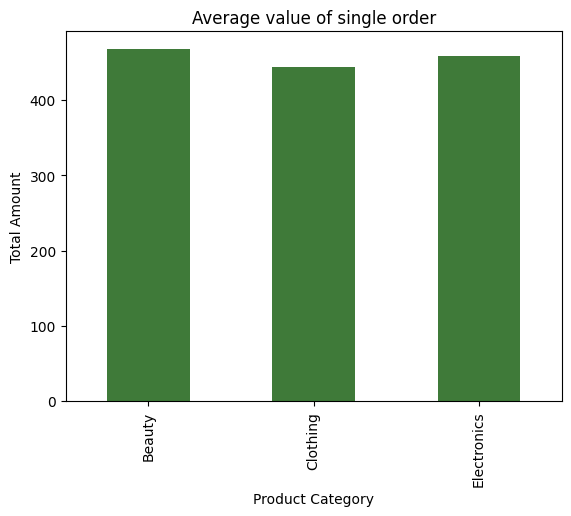

In [136]:
average_value_of_single_order.plot(kind='bar', color="#3F7A39")
plt.title('Average value of single order')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.savefig('average_value_of_single_order.png',dpi=300,bbox_inches='tight')
plt.show()

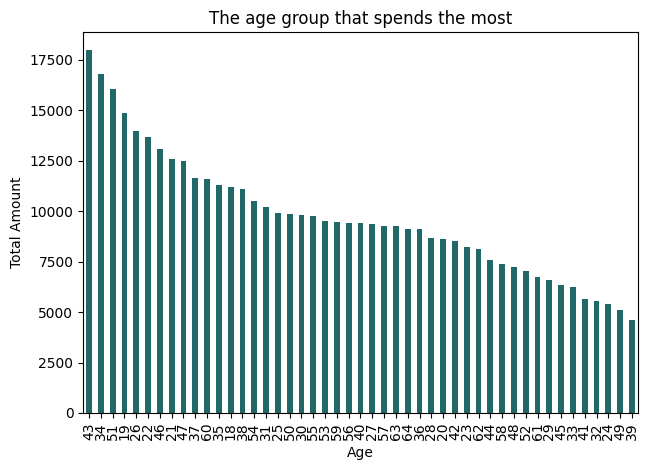

In [137]:

age_group.plot(kind='bar', color="#216969")
plt.title('The age group that spends the most')
plt.xticks(rotation=90 )
plt.tight_layout()
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.savefig('age_group.png',dpi=300,bbox_inches='tight')
plt.show()

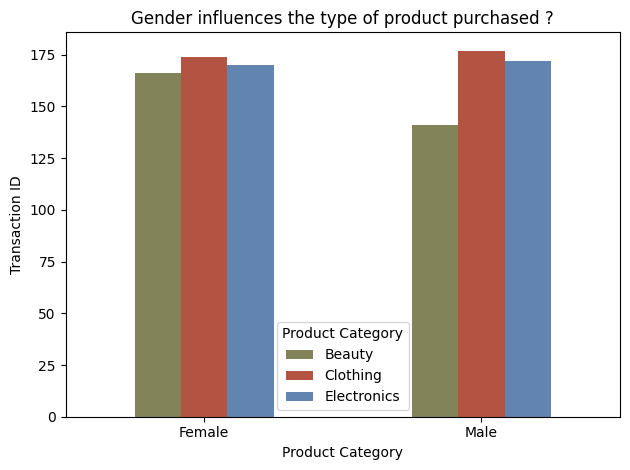

In [138]:
Gender_influences.unstack().plot(kind='bar',color=["#838359",'#B35442',"#6184B1"])
plt.title('Gender influences the type of product purchased ?')
plt.xlabel('Product Category')
plt.ylabel('Transaction ID')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Gender_influences.png',dpi=300,bbox_inches='tight')
plt.show()